# Variational quantum classifier

Train a two-qubit VQC on two Gaussian blobs and plot its decision boundary. The code lives in `src/qnn_classifier.py`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
import matplotlib.pyplot as plt
import numpy as np

from src.qnn_classifier import QNNClassifier, make_dataset

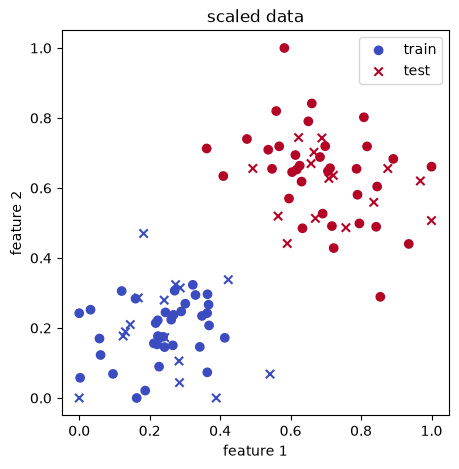

In [2]:
data = make_dataset(num_samples=100, seed=1)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(*data.x_train.T, c=data.y_train, cmap="coolwarm", label="train")
ax.scatter(*data.x_test.T, c=data.y_test, cmap="coolwarm", marker="x", label="test")
ax.set(xlabel="feature 1", ylabel="feature 2", title="scaled data")
ax.legend();

In [3]:
model = QNNClassifier(seed=1).fit(data.x_train, data.y_train)
print(f"train accuracy {model.score(data.x_train, data.y_train):.1%}")
print(f"test accuracy  {model.score(data.x_test, data.y_test):.1%}")

train accuracy 97.1%
test accuracy  96.7%


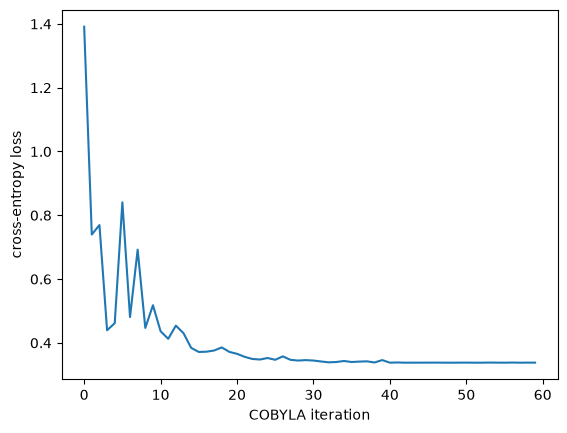

In [4]:
plt.plot(model.loss_history)
plt.xlabel("COBYLA iteration")
plt.ylabel("cross-entropy loss");

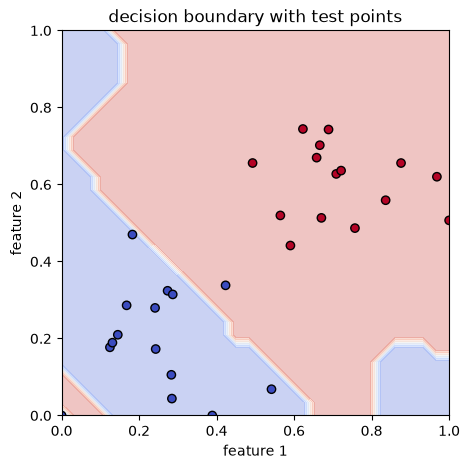

In [5]:
grid = np.linspace(0, 1, 30)
xx, yy = np.meshgrid(grid, grid)
zz = model.predict(np.column_stack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(5, 5))
ax.contourf(xx, yy, zz, cmap="coolwarm", alpha=0.3)
ax.scatter(*data.x_test.T, c=data.y_test, cmap="coolwarm", edgecolor="k")
ax.set(xlabel="feature 1", ylabel="feature 2", title="decision boundary with test points");